# NB 02: PCA Factor Extraction

**Objective**: Extract PCA factors from the 60d vol surface and validate PC2 as a skew measure. Compare with raw skew metric from NB 01.

**Key Questions**:
- How much variance does each PC explain?
- Does PC2 have interpretable loadings (monotonic, skew-like)?
- How correlated is PC2 with the simple `skew_25_10` metric?
- Are loadings stable over time, or do they drift?

**Data**: `surface_data_60d.parquet` (ATM-demeaned put-wing IV across 17 moneyness points)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from walk_forward import get_surface_columns

plt.rcParams.update({
    'figure.figsize': (14, 6),
    # 'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Load Data & Prepare for PCA

In [2]:
surface = pl.read_parquet('../data/surface_data.parquet').sort('date')
print(f"Surface shape: {surface.shape}")
print(f"Date range: {surface['date'].min()} to {surface['date'].max()}")

# Get surface columns (sorted by moneyness)
surface_cols, x_grid = get_surface_columns(surface, "int_surface_vol_")
print(f"\nSurface columns ({len(surface_cols)}):")
for c, x in zip(surface_cols, x_grid):
    print(f"  {c:25s}  moneyness = {x:+.3f}")

# Drop ATM column (all zeros after demeaning)
keep_mask = ~np.isclose(x_grid, 0.0)
cols_use = [c for c, k in zip(surface_cols, keep_mask) if k]
x_use = x_grid[keep_mask]
deep_otm_idx = int(np.argmin(x_use))
print(f"\nUsing {len(cols_use)} columns (dropped ATM)")
print(f"Deep OTM index: {deep_otm_idx} (moneyness = {x_use[deep_otm_idx]:.2f})")

# Extract matrix
X = surface.select(cols_use).to_numpy().astype(np.float64)
dates = surface['date'].to_list()
print(f"Data matrix shape: {X.shape}")

# Check for NaN
nan_count = np.isnan(X).sum()
print(f"NaN values: {nan_count}")
if nan_count > 0:
    # Drop rows with NaN
    valid_mask = ~np.any(np.isnan(X), axis=1)
    X = X[valid_mask]
    dates = [d for d, v in zip(dates, valid_mask) if v]
    print(f"After dropping NaN rows: {X.shape}")

Surface shape: (2784, 22)
Date range: 2015-01-02 to 2026-03-19

Surface columns (17):
  int_surface_vol_-0.3       moneyness = -0.300
  int_surface_vol_-0.25      moneyness = -0.250
  int_surface_vol_-0.2       moneyness = -0.200
  int_surface_vol_-0.17      moneyness = -0.170
  int_surface_vol_-0.14      moneyness = -0.140
  int_surface_vol_-0.12      moneyness = -0.120
  int_surface_vol_-0.1       moneyness = -0.100
  int_surface_vol_-0.09      moneyness = -0.090
  int_surface_vol_-0.08      moneyness = -0.080
  int_surface_vol_-0.07      moneyness = -0.070
  int_surface_vol_-0.06      moneyness = -0.060
  int_surface_vol_-0.05      moneyness = -0.050
  int_surface_vol_-0.04      moneyness = -0.040
  int_surface_vol_-0.03      moneyness = -0.030
  int_surface_vol_-0.02      moneyness = -0.020
  int_surface_vol_-0.01      moneyness = -0.010
  int_surface_vol_0.0        moneyness = +0.000

Using 16 columns (dropped ATM)
Deep OTM index: 0 (moneyness = -0.30)
Data matrix shape: (2784, 16

## 2. Full-Sample PCA (for interpretation only)

**WARNING**: This is full-sample PCA with look-ahead bias. Used only for understanding factor structure, not for signal generation. Walk-forward PCA (NB 03) is used for actual trading signals.

PC1 captures 86.4% of variance (level), PC2 captures 11.1% (skew). Two factors explain 97.5% — the put wing is effectively 2-dimensional.

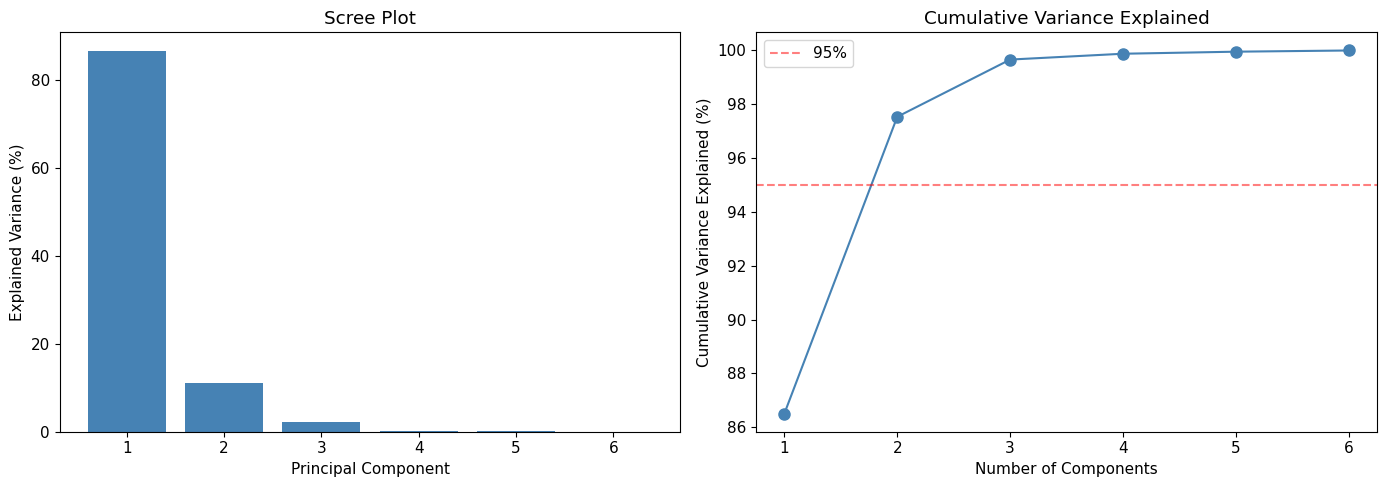

Explained Variance Ratios:
  PC1: 86.51% (cumulative: 86.51%)
  PC2: 11.00% (cumulative: 97.51%)
  PC3: 2.12% (cumulative: 99.63%)
  PC4: 0.22% (cumulative: 99.85%)
  PC5: 0.08% (cumulative: 99.92%)
  PC6: 0.04% (cumulative: 99.97%)


In [3]:
# Standardize
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# Fit PCA
pca = PCA(n_components=min(6, X.shape[1]))
scores = pca.fit_transform(Z)
loadings = pca.components_.T  # (n_features, n_components)

# Sign-fix: positive PC2 = steep skew (positive loading at deep OTM)
if loadings[deep_otm_idx, 1] < 0:
    loadings[:, 1] *= -1
    scores[:, 1] *= -1
    print("PC2 sign-flipped so positive = steep skew")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

evr = pca.explained_variance_ratio_
axes[0].bar(range(1, len(evr)+1), evr * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')

# Cumulative
axes[1].plot(range(1, len(evr)+1), np.cumsum(evr) * 100, 'o-', color='steelblue', markersize=8)
axes[1].axhline(95, color='red', linestyle='--', alpha=0.5, label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

fig.tight_layout()
plt.show()

print("Explained Variance Ratios:")
for i, ev in enumerate(evr):
    print(f"  PC{i+1}: {ev*100:.2f}% (cumulative: {np.sum(evr[:i+1])*100:.2f}%)")

## 3. Loading Vectors

PC1: All-positive, roughly flat — a parallel shift of the entire put wing (level). PC2: Monotonically decreasing from +0.56 at deep OTM (-0.30) to -0.32 near ATM (-0.01), crossing zero around moneyness -0.094. This is a clean tilt/slope factor. PC3: Curvature (U-shaped), ~2% variance — noise.

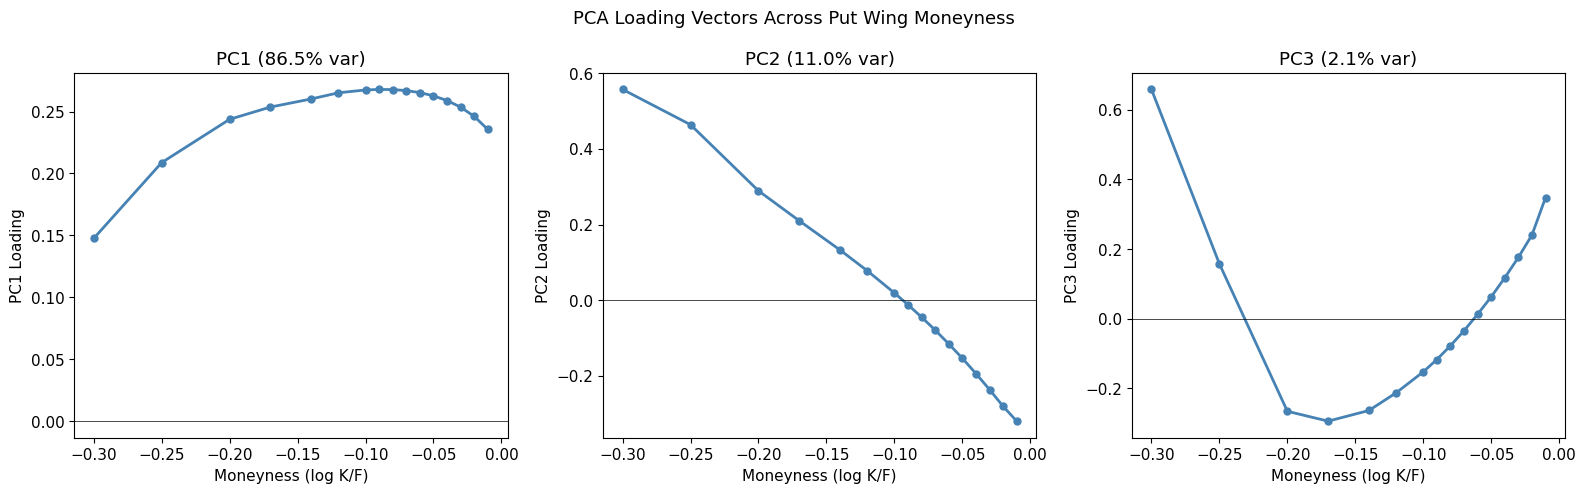

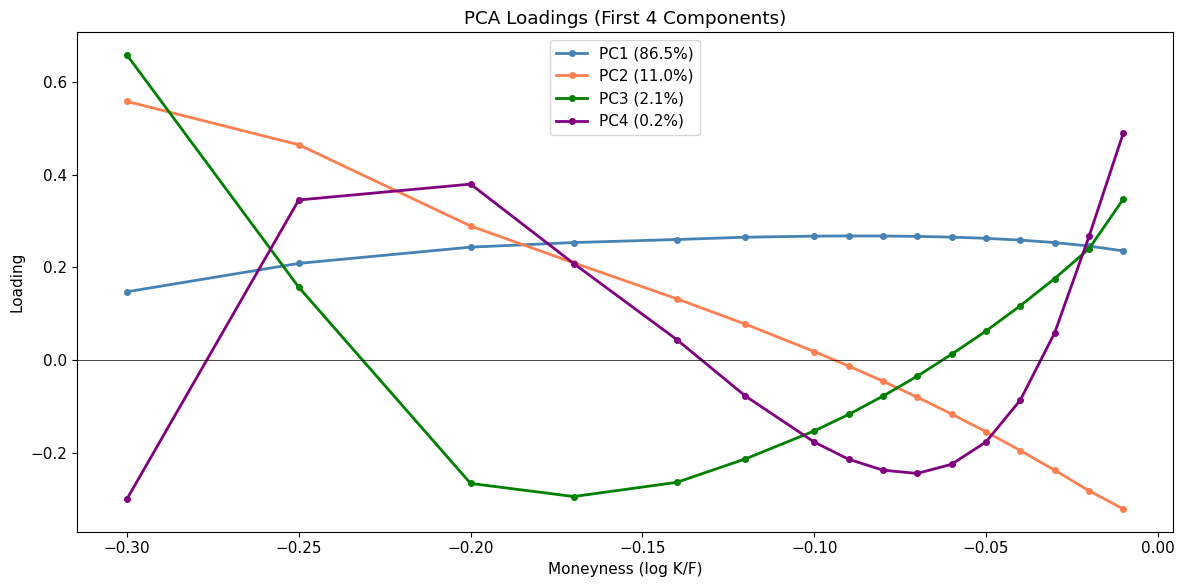

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, ax in enumerate(axes):
    ax.plot(x_use, loadings[:, i], 'o-', color='steelblue', markersize=5, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Moneyness (log K/F)')
    ax.set_ylabel(f'PC{i+1} Loading')
    ax.set_title(f'PC{i+1} ({evr[i]*100:.1f}% var)')

fig.suptitle('PCA Loading Vectors Across Put Wing Moneyness', fontsize=13)
fig.tight_layout()
plt.show()

# All loadings on one plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'brown']
for i in range(min(4, loadings.shape[1])):
    ax.plot(x_use, loadings[:, i], 'o-', color=colors[i], markersize=4,
            linewidth=2, label=f'PC{i+1} ({evr[i]*100:.1f}%)')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Moneyness (log K/F)')
ax.set_ylabel('Loading')
ax.set_title('PCA Loadings (First 4 Components)')
ax.legend()
fig.tight_layout()
plt.show()

## 4. PC2 Sign Convention & Interpretation

PC2 loading: +0.56 at x=-0.30, decreasing monotonically, crossing zero at x ~ -0.094, down to -0.32 at x=-0.01. Strictly monotonic (15/15 segments decreasing). The zero-crossing at -0.094 means PC2 separates the wing into deep OTM (x < -0.09, positive loading) and near-ATM (x > -0.09, negative loading). Options near the zero-crossing contribute nothing to the skew factor.

In [5]:
print("PC2 Loading Analysis:")
print(f"  Loading at deepest OTM ({x_use[deep_otm_idx]:.2f}): {loadings[deep_otm_idx, 1]:+.4f}")
print(f"  Loading at nearest ATM ({x_use[-1]:.2f}):  {loadings[-1, 1]:+.4f}")
print(f"  Loading range: [{loadings[:, 1].min():+.4f}, {loadings[:, 1].max():+.4f}]")

# Check monotonicity
diffs = np.diff(loadings[:, 1])
n_decreasing = np.sum(diffs < 0)
print(f"\n  Monotonicity check: {n_decreasing}/{len(diffs)} segments are decreasing")
print(f"  {'MONOTONICALLY DECREASING' if n_decreasing == len(diffs) else 'NOT STRICTLY MONOTONIC'} from deep OTM to ATM")

# Zero crossing
zero_cross_idx = None
for i in range(len(loadings[:, 1]) - 1):
    if loadings[i, 1] * loadings[i+1, 1] < 0:
        # Linear interpolation for crossing point
        x_cross = x_use[i] + (0 - loadings[i, 1]) / (loadings[i+1, 1] - loadings[i, 1]) * (x_use[i+1] - x_use[i])
        zero_cross_idx = i
        print(f"  Zero crossing at moneyness ~ {x_cross:.3f} (between {x_use[i]:.3f} and {x_use[i+1]:.3f})")
        break

if zero_cross_idx is None:
    print("  No zero crossing found — PC2 is same-sign across entire wing")

PC2 Loading Analysis:
  Loading at deepest OTM (-0.30): +0.5578
  Loading at nearest ATM (-0.01):  -0.3206
  Loading range: [-0.3206, +0.5578]

  Monotonicity check: 15/15 segments are decreasing
  MONOTONICALLY DECREASING from deep OTM to ATM
  Zero crossing at moneyness ~ -0.094 (between -0.100 and -0.090)


## 5. PC2 vs Raw Skew Correlation

Corr(PC2, skew_25_10) = 0.886 — high but not >0.9. PC2 captures additional structure beyond the two-point skew metric. This makes sense: PC2 uses the full 16-point wing shape, weighted by variance contribution, while skew_25_10 only uses two points.

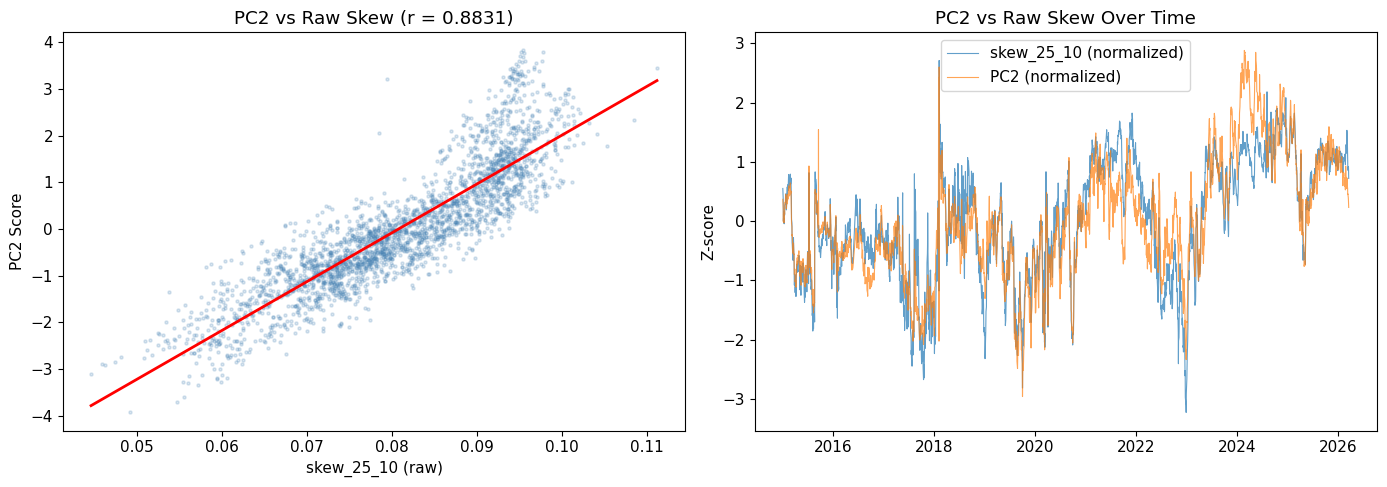

Correlation(PC2, skew_25_10): 0.8831
HIGH — PC2 captures additional structure beyond the simple skew metric.


In [6]:
# Compute raw skew from surface data
surface_aligned = surface.filter(pl.col('date').is_in(dates))
skew_25_10 = (surface_aligned['int_surface_vol_-0.25'] - surface_aligned['int_surface_vol_-0.1']).to_numpy()
pc2_scores = scores[:, 1]

# Ensure alignment
assert len(skew_25_10) == len(pc2_scores), f"Length mismatch: {len(skew_25_10)} vs {len(pc2_scores)}"

corr = np.corrcoef(skew_25_10, pc2_scores)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(skew_25_10, pc2_scores, alpha=0.2, s=5, color='steelblue')
m, b = np.polyfit(skew_25_10, pc2_scores, 1)
x_line = np.linspace(skew_25_10.min(), skew_25_10.max(), 100)
axes[0].plot(x_line, m * x_line + b, 'r-', linewidth=2)
axes[0].set_xlabel('skew_25_10 (raw)')
axes[0].set_ylabel('PC2 Score')
axes[0].set_title(f'PC2 vs Raw Skew (r = {corr:.4f})')

# Time series overlay (normalized)
ax2 = axes[1]
norm_skew = (skew_25_10 - skew_25_10.mean()) / skew_25_10.std()
norm_pc2 = (pc2_scores - pc2_scores.mean()) / pc2_scores.std()
ax2.plot(dates, norm_skew, label='skew_25_10 (normalized)', alpha=0.7, linewidth=0.8)
ax2.plot(dates, norm_pc2, label='PC2 (normalized)', alpha=0.7, linewidth=0.8)
ax2.set_ylabel('Z-score')
ax2.set_title('PC2 vs Raw Skew Over Time')
ax2.legend()

fig.tight_layout()
plt.show()

print(f"Correlation(PC2, skew_25_10): {corr:.4f}")
print(f"{'VERY HIGH' if abs(corr) > 0.9 else 'HIGH' if abs(corr) > 0.7 else 'MODERATE'} — ", end='')
if abs(corr) > 0.9:
    print("PC2 is essentially a rotation of the raw skew metric. PCA adds interpretability but not information.")
else:
    print("PC2 captures additional structure beyond the simple skew metric.")

## 6. PC2 vs Individual Moneyness Points

PC2 correlation with individual moneyness IVs shows a clear gradient: +0.74 at x=-0.30, declining through zero around x=-0.10, to -0.43 at x=-0.01. The correlation is material (|r| > 0.2) only for x <= -0.17 and x >= -0.05. The middle zone (x ~ -0.10 to -0.12) is near zero — options at these moneyness points carry almost no skew exposure.

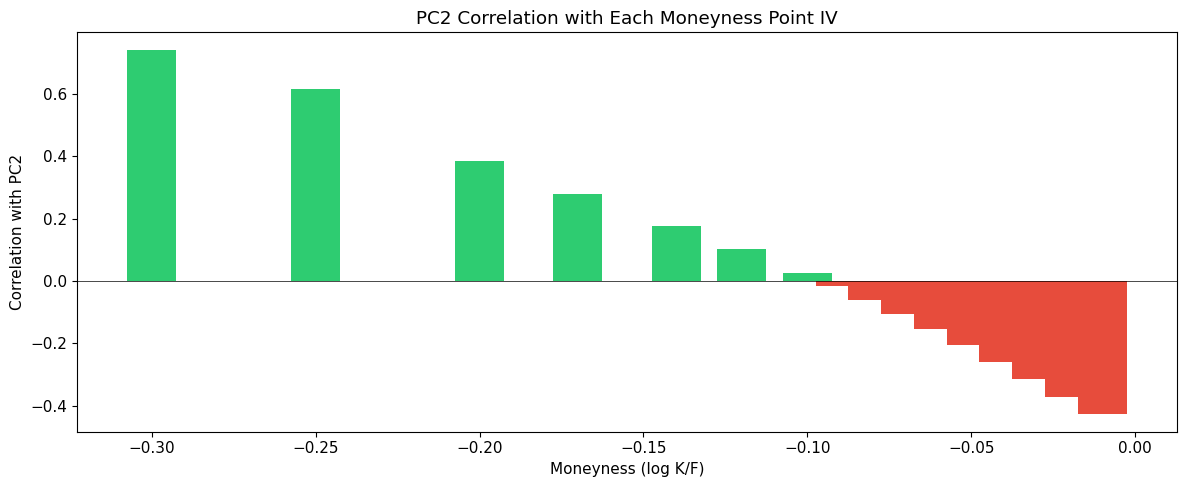

Correlation of PC2 with each moneyness IV:
  int_surface_vol_-0.3       corr = +0.7399
  int_surface_vol_-0.25      corr = +0.6159
  int_surface_vol_-0.2       corr = +0.3837
  int_surface_vol_-0.17      corr = +0.2785
  int_surface_vol_-0.14      corr = +0.1758
  int_surface_vol_-0.12      corr = +0.1031
  int_surface_vol_-0.1       corr = +0.0249
  int_surface_vol_-0.09      corr = -0.0165
  int_surface_vol_-0.08      corr = -0.0599
  int_surface_vol_-0.07      corr = -0.1055
  int_surface_vol_-0.06      corr = -0.1538
  int_surface_vol_-0.05      corr = -0.2044
  int_surface_vol_-0.04      corr = -0.2582
  int_surface_vol_-0.03      corr = -0.3143
  int_surface_vol_-0.02      corr = -0.3732
  int_surface_vol_-0.01      corr = -0.4253


In [7]:
# Compute correlation of PC2 with each moneyness column
corrs = []
for i, col in enumerate(cols_use):
    r = np.corrcoef(pc2_scores, X[:, i])[0, 1]
    corrs.append({'moneyness': x_use[i], 'column': col, 'corr_pc2': r})

corr_df = pl.DataFrame(corrs).sort('moneyness')

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr_df['corr_pc2'].to_list()]
ax.bar(corr_df['moneyness'].to_list(), corr_df['corr_pc2'].to_list(), color=colors, width=0.015)
ax.set_xlabel('Moneyness (log K/F)')
ax.set_ylabel('Correlation with PC2')
ax.set_title('PC2 Correlation with Each Moneyness Point IV')
ax.axhline(0, color='k', linewidth=0.5)
fig.tight_layout()
plt.show()

print("Correlation of PC2 with each moneyness IV:")
for row in corr_df.iter_rows(named=True):
    print(f"  {row['column']:25s}  corr = {row['corr_pc2']:+.4f}")

## 7. PC2 Time Series

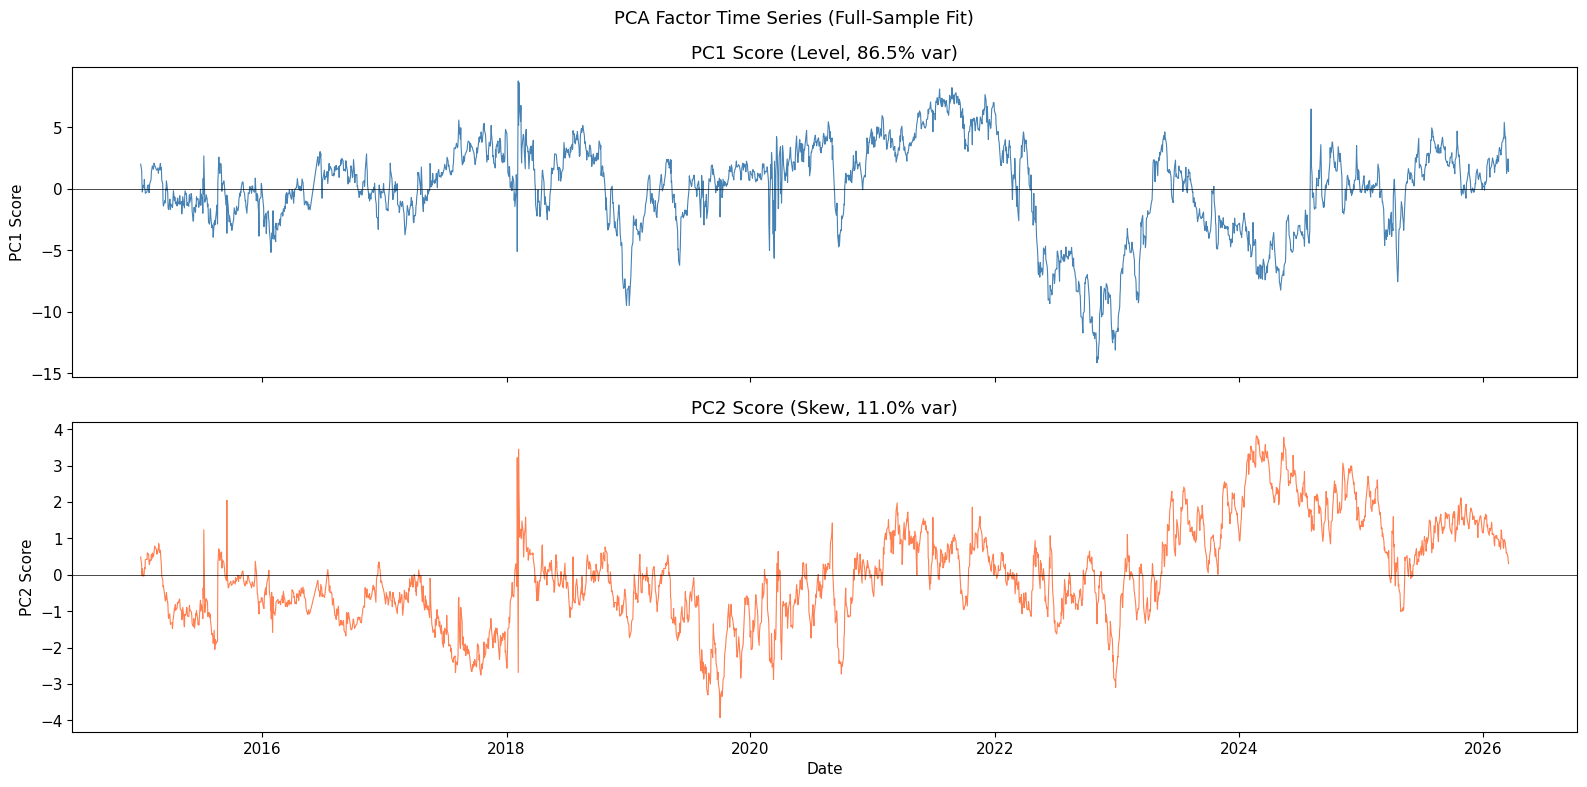

PC1 (Level): mean=0.0000, std=3.7205, min=-14.1390, max=8.7858
PC2 (Skew): mean=0.0000, std=1.3265, min=-3.9252, max=3.8213


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# PC1
axes[0].plot(dates, scores[:, 0], linewidth=0.8, color='steelblue')
axes[0].set_ylabel('PC1 Score')
axes[0].set_title(f'PC1 Score (Level, {evr[0]*100:.1f}% var)')
axes[0].axhline(0, color='k', linewidth=0.5)

# PC2
axes[1].plot(dates, scores[:, 1], linewidth=0.8, color='coral')
axes[1].set_ylabel('PC2 Score')
axes[1].set_title(f'PC2 Score (Skew, {evr[1]*100:.1f}% var)')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Date')

fig.suptitle('PCA Factor Time Series (Full-Sample Fit)', fontsize=13)
fig.tight_layout()
plt.show()

# Summary stats
for i, name in enumerate(['PC1 (Level)', 'PC2 (Skew)']):
    s = scores[:, i]
    print(f"{name}: mean={s.mean():.4f}, std={s.std():.4f}, "
          f"min={s.min():.4f}, max={s.max():.4f}")

## 8. Loading Stability Over Time

PC1 loadings are very stable (cosine similarity >0.975 across all pairs). PC2 loadings are stable between middle and last third (0.998) but drift from the first third (0.80 and 0.79 vs later periods). This early-period instability — likely driven by the shorter sample and different vol regime (2015-2018 vs post-2018) — is exactly why walk-forward PCA is necessary: the factor definition evolves.

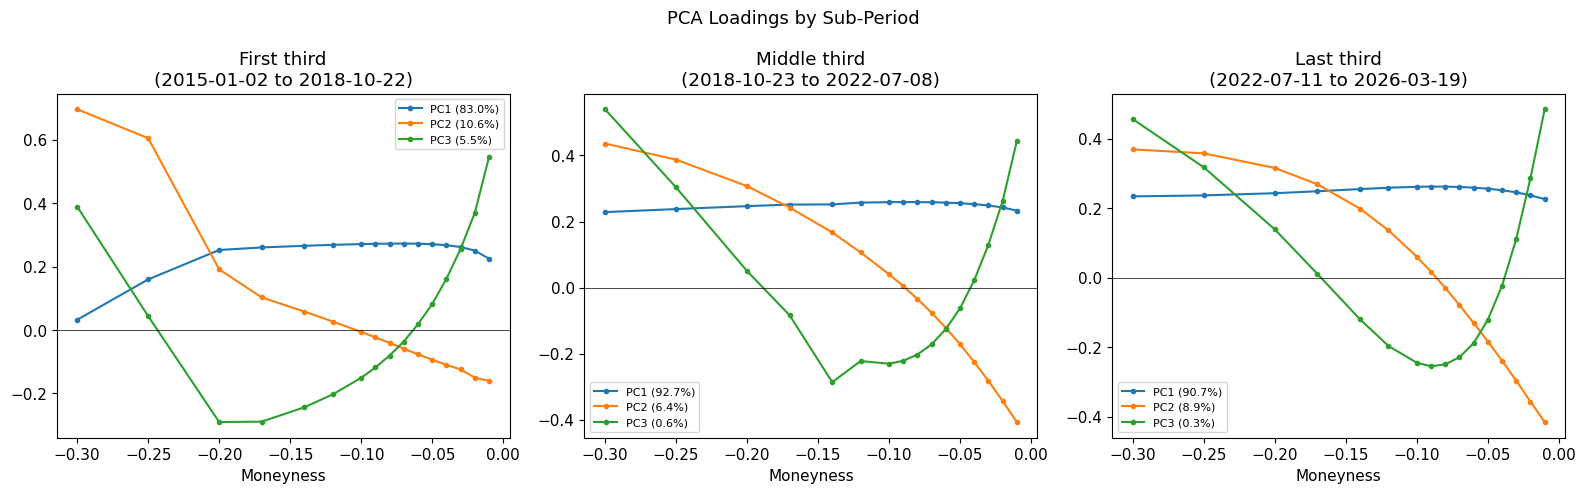


PC2 Loading Cosine Similarity Between Periods:
  First third vs Middle third: 0.8428
  First third vs Last third: 0.7927
  Middle third vs Last third: 0.9953

PC1 Loading Cosine Similarity Between Periods:
  First third vs Middle third: 0.9767
  First third vs Last third: 0.9758
  Middle third vs Last third: 0.9999


In [9]:
# Split data into 3 sub-periods
n = len(X)
split1 = n // 3
split2 = 2 * n // 3

periods = [
    ('First third', X[:split1], dates[:split1]),
    ('Middle third', X[split1:split2], dates[split1:split2]),
    ('Last third', X[split2:], dates[split2:]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

loadings_by_period = {}
for ax, (period_name, X_sub, dates_sub) in zip(axes, periods):
    scaler_sub = StandardScaler()
    Z_sub = scaler_sub.fit_transform(X_sub)
    pca_sub = PCA(n_components=3)
    pca_sub.fit(Z_sub)
    L = pca_sub.components_.T
    
    # Sign-fix PC2
    if L[deep_otm_idx, 1] < 0:
        L[:, 1] *= -1
    
    loadings_by_period[period_name] = L
    
    for i in range(3):
        ax.plot(x_use, L[:, i], 'o-', markersize=3, linewidth=1.5,
                label=f'PC{i+1} ({pca_sub.explained_variance_ratio_[i]*100:.1f}%)')
    
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Moneyness')
    ax.set_title(f'{period_name}\n({dates_sub[0]} to {dates_sub[-1]})')
    ax.legend(fontsize=8)

fig.suptitle('PCA Loadings by Sub-Period', fontsize=13)
fig.tight_layout()
plt.show()

# Quantify stability: cosine similarity between sub-period loadings
from numpy.linalg import norm
names = list(loadings_by_period.keys())
print("\nPC2 Loading Cosine Similarity Between Periods:")
for i in range(len(names)):
    for j in range(i+1, len(names)):
        L1 = loadings_by_period[names[i]][:, 1]
        L2 = loadings_by_period[names[j]][:, 1]
        cos_sim = np.dot(L1, L2) / (norm(L1) * norm(L2))
        print(f"  {names[i]} vs {names[j]}: {cos_sim:.4f}")

print("\nPC1 Loading Cosine Similarity Between Periods:")
for i in range(len(names)):
    for j in range(i+1, len(names)):
        L1 = loadings_by_period[names[i]][:, 0]
        L2 = loadings_by_period[names[j]][:, 0]
        cos_sim = np.dot(L1, L2) / (norm(L1) * norm(L2))
        print(f"  {names[i]} vs {names[j]}: {cos_sim:.4f}")

## 9. Discussion

**Results**:

1. **Two-factor surface**: PC1 (86.4%) + PC2 (11.1%) = 97.5%. The put wing is essentially 2D.
2. **PC2 is a clean skew factor**: Monotonically decreasing loadings, zero-crossing at x ~ -0.094. Interpretable and stable (post-2018).
3. **PC2 vs raw skew**: r = 0.886. Correlated but not redundant — PCA captures more than two points.
4. **Loading drift**: PC2 loadings shift in the early period (cosine sim ~0.80). Walk-forward PCA (NB 03) is necessary, not optional.
5. **Skew exposure lives deep OTM**: PC2 correlation is material only at x <= -0.17 (corr > +0.2) and x >= -0.05 (corr < -0.2). The zone around x = -0.10 is a dead zone for skew exposure.

**Trade structure implication**: To express a PC2 view, the short leg needs to be deep enough OTM to have meaningful PC2 loading. Options around x = -0.10 (the zero-crossing) have ~zero skew exposure — they sit at the pivot point of the factor. 